## Generate Training Dataset (EXIST 2026 Dataset)

This notebooks generates the training dataset we are going to use for our future models. It takes the raw dataset (`Exist 2026 Dataset`) and preprocess it.

In [2]:
#Libraries
import json
from pathlib import Path
from collections import Counter
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

os.chdir("C:/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist")

In [3]:
#Path to the data
DATA_DIR = os.path.join("data", "memes", "training")
IMAGES_DIR = os.path.join(DATA_DIR, "memes")

In [4]:
#Load the data 
with open(os.path.join(DATA_DIR, "EXIST2026_training.json"), "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Convert the raw data into a list of records
records = []
for key, item in raw_data.items():
    row = item.copy()
    records.append(row)

#Dataframe creation
df = pd.DataFrame(records)
df.head()


,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,memes/110887.jpeg,6,"[Annotator_193, Annotator_194, Annotator_195, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Multiracial, White or Cau...","[High school degree or equivalent, Master’s de...","[Sweden, United States, Spain, Portugal, Spain...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, DIRECT, DIRECT, DIRECT, DIRECT, ...","[[IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [M...",TRAIN-MEME_ES
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,memes/110466.jpeg,6,"[Annotator_103, Annotator_104, Annotator_105, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, Hispa...","[Bachelor’s degree, High school degree or equi...","[Spain, Portugal, Spain, Canada, United States...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, NO, YES, YES, NO, NO]","[DIRECT, -, DIRECT, DIRECT, -, -]","[[STEREOTYPING-DOMINANCE], [-], [STEREOTYPING-...",TRAIN-MEME_ES
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,memes/111269.jpeg,6,"[Annotator_277, Annotator_278, Annotator_279, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, other,...","[Bachelor’s degree, Master’s degree, High scho...","[Spain, Spain, Spain, Italy, Spain, Portugal]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, -]","[[OBJECTIFICATION, SEXUAL-VIOLENCE], [OBJECTIF...",TRAIN-MEME_ES
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,memes/110593.jpeg,6,"[Annotator_127, Annotator_128, Annotator_129, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Master’s de...","[Poland, Portugal, Spain, United Kingdom, Mexi...","{'users': ['ES1', 'ES3'], 'modalities': {'ET':...","[NO, YES, NO, NO, NO, NO]","[-, JUDGEMENTAL, -, -, -, -]","[[-], [STEREOTYPING-DOMINANCE, OBJECTIFICATION...",TRAIN-MEME_ES
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,memes/110946.jpeg,6,"[Annotator_211, Annotator_212, Annotator_213, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[Portugal, Chile, Italy, Portugal, Spain, Chile]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[YES, YES, YES, YES, NO, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, -, -]","[[OBJECTIFICATION], [SEXUAL-VIOLENCE], [OBJECT...",TRAIN-MEME_ES


In [5]:
#Helpers

#Get the raw modality data for a given modality
def get_modality_raw(sensorial, modality):
    if not isinstance(sensorial, dict):
        return None
    return sensorial.get("modalities", {}).get(modality, {}).get("by_user", None)

# Calculate the soft labels for Task 2.1
def soft_task21(labels):
    valid = [x for x in labels if x != "UNKNOWN"]
    total = len(valid)
    if total == 0:
        return {"YES": np.nan, "NO": np.nan}
    
    counts = Counter(valid)
    return {
        "YES": counts.get("YES", 0) / total,
        "NO": counts.get("NO", 0) / total}

# Calculate the hard label for Task 2.1 based argmax 
def hard_task21(labels, threshold=3):
    valid = [x for x in labels if x != "UNKNOWN"]
    total = len(valid)
    if total == 0:
        return {"YES": np.nan, "NO": np.nan}
    
    counts = Counter(valid)

    if counts.get("YES", 0) >= counts.get("NO", 0):
        return "YES", True
    else:
        return "NO", True
    
# Calculate the soft labels for Task 2.2
def soft_task22(labels):
    valid = [x for x in labels if x not in {"UNKNOWN", "-"}]
    total = len(valid)
    if total == 0:
        return {"DIRECT": np.nan, "JUDGEMENTAL": np.nan}
    
    counts = Counter(valid)
    return {
        "DIRECT": counts.get("DIRECT", 0) / total,
        "JUDGEMENTAL": counts.get("JUDGEMENTAL", 0) / total}

# Calculate the hard label for Task 2.2 based on an official threshold
def hard_task22(labels, threshold=2):
    valid = [x for x in labels if x not in {"UNKNOWN", "-"}]
    total = len(valid)
    if total == 0:
        return "-", False
    
    counts = Counter(valid)

    if counts.get("DIRECT", 0) >= counts.get("JUDGEMENTAL", 0):
            return "DIRECT", True
    else:
            return "JUDGEMENTAL", True

# Calculate the soft labels for Task 2.3 (5 classes)
TASK23_CLASSES = ["IDEOLOGICAL-INEQUALITY","STEREOTYPING-DOMINANCE","OBJECTIFICATION","SEXUAL-VIOLENCE","MISOGYNY-NON-SEXUAL-VIOLENCE"]

def soft_task23(labels_task23):
    valid_annotators = []
    for ann_labels in labels_task23:
        if not isinstance(ann_labels, list):
            continue
        filtered = [x for x in ann_labels if x not in {"UNKNOWN", "-"}]
        valid_annotators.append(filtered)
    
    total = len(valid_annotators)
    if total == 0:
        return {c: np.nan for c in TASK23_CLASSES}
    
    counts = Counter()
    for ann_labels in valid_annotators:
        for c in ann_labels:
            counts[c] += 1
    
    return {c: counts.get(c, 0) / total for c in TASK23_CLASSES}

#Calculate the hard labels for Task 2.3 based on an official threshold
def hard_task23(labels_task23, threshold=1):
    valid_annotators = []
    for ann_labels in labels_task23:
        if not isinstance(ann_labels, list):
            continue
        filtered = [x for x in ann_labels if x not in {"UNKNOWN", "-"}]
        valid_annotators.append(filtered)
    
    if len(valid_annotators) == 0:
        return [], False
    
    counts = Counter()
    for ann_labels in valid_annotators:
        for c in ann_labels:
            counts[c] += 1
    
    hard_labels = {c: int(counts.get(c, 0) > threshold) for c in TASK23_CLASSES}
    
    return hard_labels, any(hard_labels.values())

In [6]:
rows = []

for _, row in df.iterrows():
    task21_soft = soft_task21(row["labels_task2_1"])
    task21_hard, task21_valid = hard_task21(row["labels_task2_1"])
    
    task22_soft = soft_task22(row["labels_task2_2"])
    task22_hard, task22_valid = hard_task22(row["labels_task2_2"])
    
    task23_soft = soft_task23(row["labels_task2_3"])
    task23_hard, task23_valid = hard_task23(row["labels_task2_3"])
    
    new_row = {
        "id": row["id_EXIST"],
        "lang": row["lang"],
        "text": row["text"],
        "image_file": row["meme"],
        "split": "Train",
        
        "ET_raw": get_modality_raw(row["sensorial"], "ET"),
        "HR_raw": get_modality_raw(row["sensorial"], "HR"),
        "EEG_raw": get_modality_raw(row["sensorial"], "EEG"),
        
        "task21_hard": task21_hard,
        "task21_valid_hard": task21_valid,
        "task21_soft": task21_soft,
        
        "task22_hard": task22_hard,
        "task22_valid_hard": task22_valid,
        "task22_soft": task22_soft,
        
        "task23_hard": task23_hard,
        "task23_valid_hard": task23_valid,
        "task23_soft": task23_soft,
    }
    
    rows.append(new_row)

train_base = pd.DataFrame(rows)
train_base.head(5)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",YES,True,"{'YES': 1.0, 'NO': 0.0}",DIRECT,True,"{'DIRECT': 0.8333333333333334, 'JUDGEMENTAL': ...","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",YES,True,"{'YES': 0.5, 'NO': 0.5}",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'ES2': {'reaction_time': 9692.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 60.2, 'garmin_hr_st...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6395, ...",YES,True,"{'YES': 0.8333333333333334, 'NO': 0.1666666666...",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'ES3': {'reaction_time': 10421.0, '3d_eye_sta...","{'ES3': {'garmin_hr_mean': 68.4545, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6614, ...",NO,True,"{'YES': 0.16666666666666666, 'NO': 0.833333333...",JUDGEMENTAL,True,"{'DIRECT': 0.0, 'JUDGEMENTAL': 1.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",False,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'ES2': {'reaction_time': 5174.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 68.3333, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.0069, ...",YES,True,"{'YES': 0.6666666666666666, 'NO': 0.3333333333...",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."


## 2.1 Binary Classification (Sexism)

In [7]:
# We can directly map the hard labels to binary values 
# 2.1 is a binary classification task, so we can convert the "YES"/"NO" labels to 1/0
# and soft labels to the probability of "YES"

task21_hard_map = {"YES": 1, "NO": 0}
train_base["task21_hard"] = train_base["task21_hard"].map(task21_hard_map)
train_base["task21_soft"] = train_base["task21_soft"].apply(lambda x: x.get("YES"))
train_base.head(2)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",1,True,1.0,DIRECT,True,"{'DIRECT': 0.8333333333333334, 'JUDGEMENTAL': ...","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",1,True,0.5,DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...


## 2.2 Binary Classification (Intention Detection)

In [8]:
# We can directly map the hard labels to binary values 
# 2.2 is a binary classification task, so we can convert the "DIRECT"/"JUDGEMENTAL" labels to 1/0
# and soft labels to the probability of "DIRECT"

task22_hard_map = {"DIRECT": 1, "JUDGEMENTAL": 0}
train_base["task22_hard"] = train_base["task22_hard"].map(task22_hard_map)
train_base["task22_soft"] = train_base["task22_soft"].apply(lambda x: x.get("DIRECT"))
train_base.head(2)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",1,True,1.0,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",1,True,0.5,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...


## Label Distribution
### Task 2.1

In [9]:
print("Task 2.1 soft")
print(train_base["task21_soft"].describe())

Task 2.1 soft
count    3984.000000
mean        0.555807
std         0.313998
min         0.000000
25%         0.333333
50%         0.666667
75%         0.833333
max         1.000000
Name: task21_soft, dtype: float64


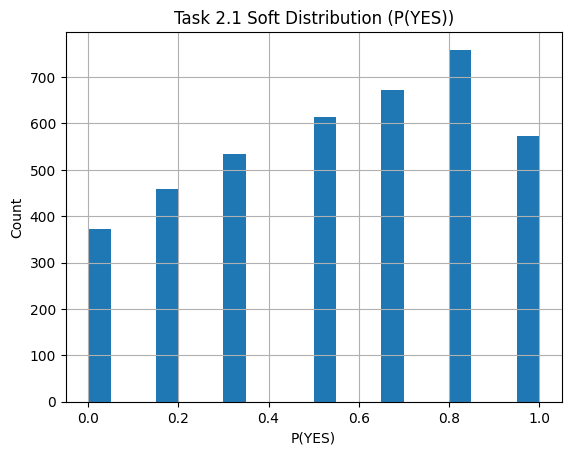

In [13]:
train_base["task21_soft"].hist(bins=20)
plt.title("Task 2.1 Soft Distribution (P(YES))")
plt.xlabel("P(YES)")
plt.ylabel("Count")
plt.show()

In [14]:
print("Task 2.1 soft exact values")
print(train_base["task21_soft"].value_counts().sort_index())

Task 2.1 soft exact values
0.000000    373
0.166667    459
0.333333    535
0.500000    614
0.666667    672
0.833333    759
1.000000    572
Name: task21_soft, dtype: int64


### Task 2.2

In [15]:
print("Task 2.2 hard (all rows)")
print(train_base["task22_hard"].value_counts(dropna=False).sort_index())

print("\nTask 2.2 valid_hard")
print(train_base["task22_valid_hard"].value_counts(dropna=False))

Task 2.2 hard (all rows)
0.0     909
1.0    2694
NaN     381
Name: task22_hard, dtype: int64

Task 2.2 valid_hard
True     3603
False     381
Name: task22_valid_hard, dtype: int64


In [16]:
task22_valid = train_base[train_base["task22_valid_hard"] == True]

print("Task 2.2 hard (valid only)")
print(task22_valid["task22_hard"].value_counts(dropna=False).sort_index())
print(task22_valid["task22_hard"].value_counts(normalize=True, dropna=False).sort_index())

Task 2.2 hard (valid only)
0.0     909
1.0    2694
Name: task22_hard, dtype: int64
0.0    0.25229
1.0    0.74771
Name: task22_hard, dtype: float64


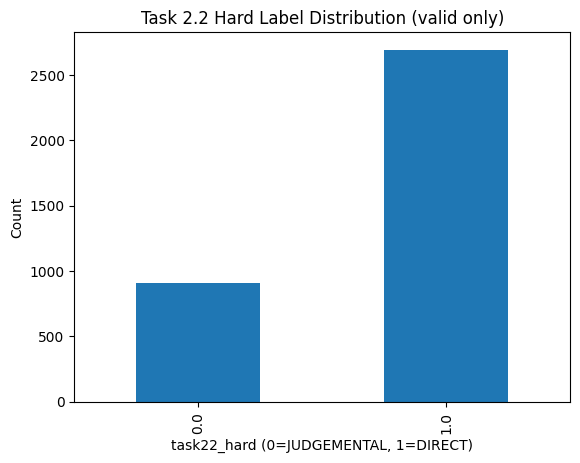

In [17]:
task22_valid["task22_hard"].value_counts().sort_index().plot(kind="bar")
plt.title("Task 2.2 Hard Label Distribution (valid only)")
plt.xlabel("task22_hard (0=JUDGEMENTAL, 1=DIRECT)")
plt.ylabel("Count")
plt.show()

In [18]:
print("Task 2.2 soft")
print(train_base["task22_soft"].describe())
print(train_base["task22_soft"].value_counts().sort_index())

Task 2.2 soft
count    3603.000000
mean        0.625437
std         0.320554
min         0.000000
25%         0.400000
50%         0.666667
75%         1.000000
max         1.000000
Name: task22_soft, dtype: float64
0.000000    392
0.166667     17
0.200000     61
0.250000    106
0.333333    204
0.400000    129
0.500000    536
0.600000    201
0.666667    392
0.750000    215
0.800000    211
0.833333    160
1.000000    979
Name: task22_soft, dtype: int64


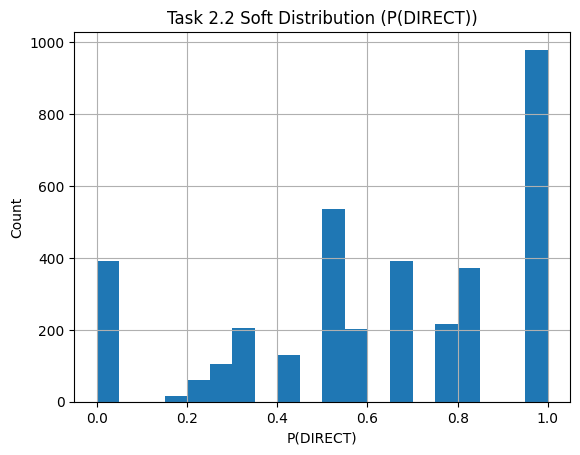

In [19]:
train_base["task22_soft"].hist(bins=20)
plt.title("Task 2.2 Soft Distribution (P(DIRECT))")
plt.xlabel("P(DIRECT)")
plt.ylabel("Count")
plt.show()

### Task 2.3 - Hard

In [20]:
task23_hard_df = train_base["task23_hard"].apply(pd.Series)
task23_hard_df.head()

,IDEOLOGICAL-INEQUALITY,STEREOTYPING-DOMINANCE,OBJECTIFICATION,SEXUAL-VIOLENCE,MISOGYNY-NON-SEXUAL-VIOLENCE
0,0,0,1,0,1
1,0,1,0,1,0
2,0,0,1,0,0
3,0,0,0,0,0
4,0,0,1,0,0


In [21]:
print("Task 2.3 hard counts by class")
print(task23_hard_df.sum().sort_values(ascending=False))

Task 2.3 hard counts by class
STEREOTYPING-DOMINANCE          1287
OBJECTIFICATION                 1202
IDEOLOGICAL-INEQUALITY          1067
SEXUAL-VIOLENCE                  563
MISOGYNY-NON-SEXUAL-VIOLENCE     448
dtype: int64


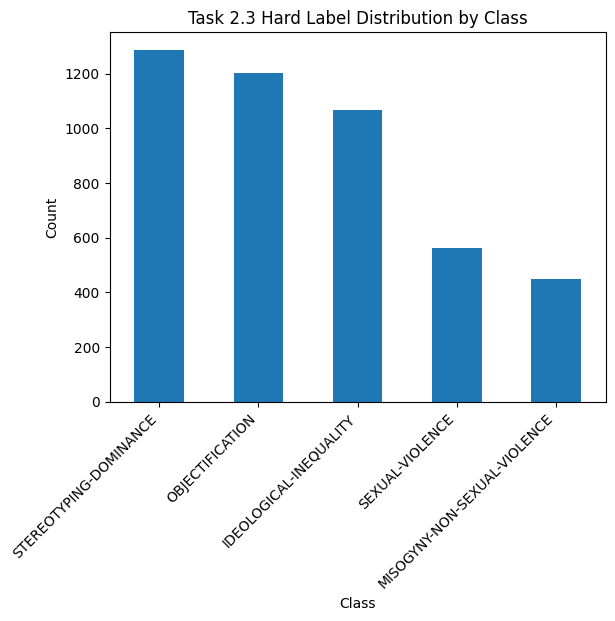

In [23]:
task23_hard_df.sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Task 2.3 Hard Label Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
#Number of hard labels per sample (Meme)
train_base["task23_num_hard_labels"] = task23_hard_df.sum(axis=1)
print(train_base["task23_num_hard_labels"].describe())
print(train_base["task23_num_hard_labels"].value_counts().sort_index())

count    3984.000000
mean        1.146335
std         0.973885
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: task23_num_hard_labels, dtype: float64
0    1156
1    1503
2     976
3     289
4      55
5       5
Name: task23_num_hard_labels, dtype: int64


In [25]:
task23_soft_df = train_base["task23_soft"].apply(pd.Series)
task23_soft_df.head()

,IDEOLOGICAL-INEQUALITY,STEREOTYPING-DOMINANCE,OBJECTIFICATION,SEXUAL-VIOLENCE,MISOGYNY-NON-SEXUAL-VIOLENCE
0,0.166667,0.166667,0.666667,0.000000,0.500000
1,0.166667,0.500000,0.166667,0.333333,0.166667
2,0.000000,0.166667,0.666667,0.166667,0.166667
3,0.000000,0.166667,0.166667,0.000000,0.000000
4,0.000000,0.000000,0.500000,0.166667,0.000000


In [26]:
print("Task 2.3 average soft probability by class")
print(task23_soft_df.mean().sort_values(ascending=False))

Task 2.3 average soft probability by class
STEREOTYPING-DOMINANCE          0.198670
OBJECTIFICATION                 0.190303
IDEOLOGICAL-INEQUALITY          0.170725
SEXUAL-VIOLENCE                 0.093081
MISOGYNY-NON-SEXUAL-VIOLENCE    0.085634
dtype: float64


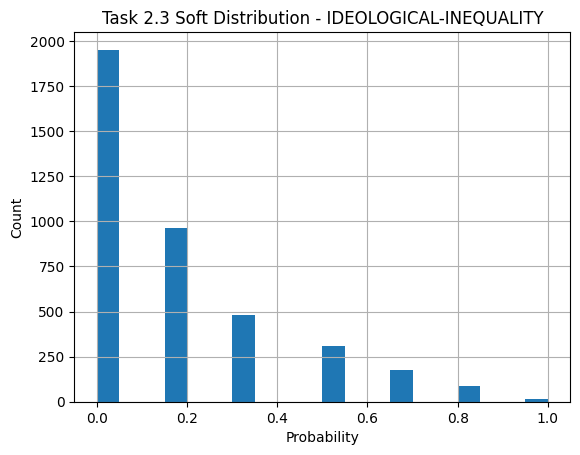

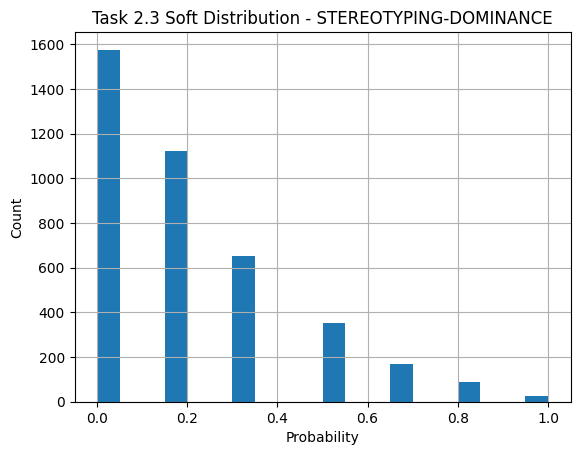

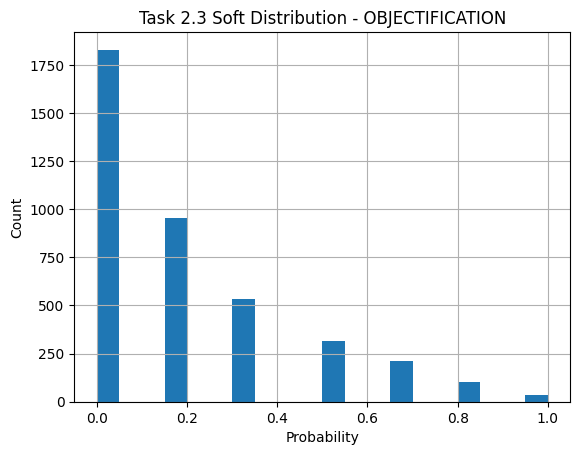

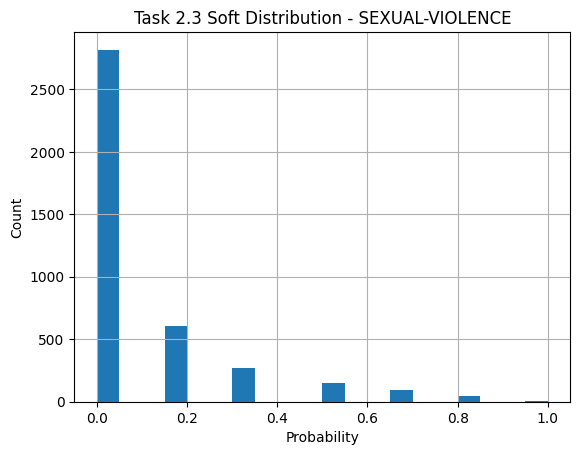

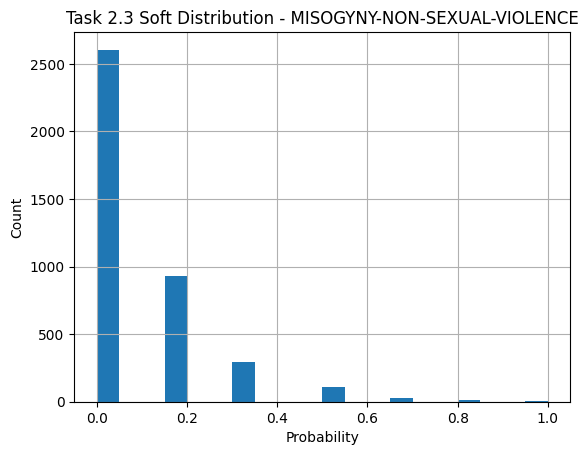

In [27]:
for col in task23_soft_df.columns:
    plt.figure()
    task23_soft_df[col].hist(bins=20)
    plt.title(f"Task 2.3 Soft Distribution - {col}")
    plt.xlabel("Probability")
    plt.ylabel("Count")
    plt.show()

## Inconsistencies

In [31]:
check_21 = train_base[
    ((train_base["task21_hard"] == 1) & (train_base["task21_soft"] < 0.5)) |
    ((train_base["task21_hard"] == 0) & (train_base["task21_soft"] >= 0.5))
]

print("Inconsistencies task21:", len(check_21))

Inconsistencies task21: 0


In [33]:
task22_valid = train_base[train_base["task22_valid_hard"] == True].copy()

check_22 = task22_valid[
    ((task22_valid["task22_hard"] == 1) & (task22_valid["task22_soft"] < 0.5)) |
    ((task22_valid["task22_hard"] == 0) & (task22_valid["task22_soft"] >= 0.5))
]

print("Inconsistencies task22:", len(check_22))

Inconsistencies task22: 0


In [34]:
for col in task23_hard_df.columns:
    inconsistent = ((task23_hard_df[col] == 1) & (task23_soft_df[col] < (1/6))).sum()
    print(col, "inconsistencies:", inconsistent)

IDEOLOGICAL-INEQUALITY inconsistencies: 0
STEREOTYPING-DOMINANCE inconsistencies: 0
OBJECTIFICATION inconsistencies: 0
SEXUAL-VIOLENCE inconsistencies: 0
MISOGYNY-NON-SEXUAL-VIOLENCE inconsistencies: 0
